# Exercise 1 — Point Clouds: Geometry and Spread in 2D

Geração e medição de nuvens de pontos 2D, observando como a dispersão afeta a
complexidade das fronteiras de decisão.

Semente fixa: `rng = np.random.default_rng(42)`, o mesmo `rng` em todo o notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)  # semente fixa exigida pelo enunciado

# Parâmetros do enunciado: média e desvio-padrão POR EIXO de cada classe
MEANS = np.array([[2, 3], [5, 6], [8, 1], [15, 4]], dtype=float)
STDS  = np.array([[0.8, 2.5], [1.2, 1.9], [0.9, 0.9], [0.5, 2.0]], dtype=float)
N_PER_CLASS = 100
COLORS = ["tab:blue", "tab:orange", "tab:green", "tab:red"]


def gen_clouds(rng, scale=1.0):
    """Gera as 4 classes (100 pontos cada) com os desvios multiplicados por `scale`."""
    X = np.vstack([
        rng.normal(MEANS[k], STDS[k] * scale, size=(N_PER_CLASS, 2))
        for k in range(4)
    ])
    y = np.repeat(np.arange(4), N_PER_CLASS)
    return X, y

## A — Generate the clouds

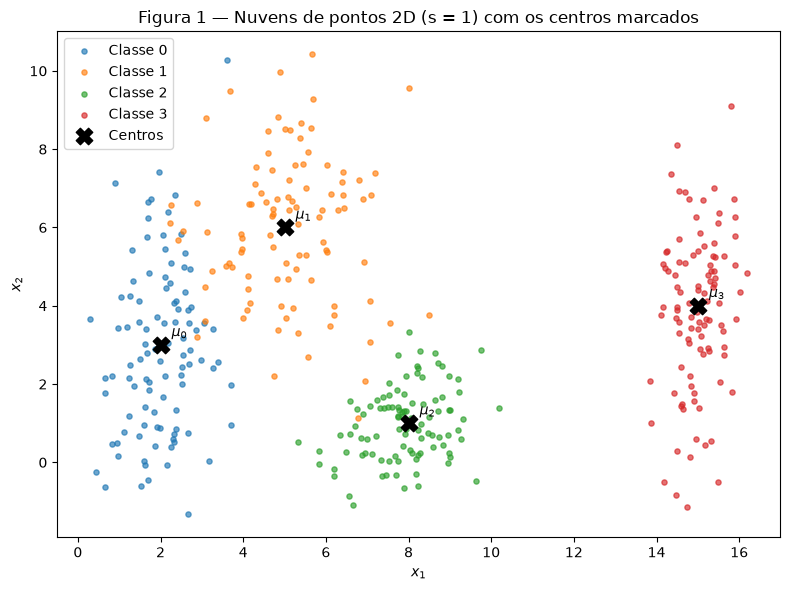

In [2]:
X1, y1 = gen_clouds(rng, scale=1.0)  # dataset original (s = 1)

fig, ax = plt.subplots(figsize=(8, 6))
for k in range(4):
    pts = X1[y1 == k]
    ax.scatter(pts[:, 0], pts[:, 1], s=14, alpha=0.65, color=COLORS[k], label=f"Classe {k}")
# centro (média) de cada nuvem marcado com X preto
ax.scatter(MEANS[:, 0], MEANS[:, 1], marker="X", s=140, color="black", zorder=5,
           label="Centros")
for k in range(4):
    ax.annotate(f"$\\mu_{k}$", MEANS[k], textcoords="offset points", xytext=(8, 6))
ax.set_title("Figura 1 — Nuvens de pontos 2D (s = 1) com os centros marcados")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.legend()
plt.tight_layout()
plt.show()

As 400 amostras (100 por classe) seguem os parâmetros do enunciado. A dispersão é
**anisotrópica**: a classe 0 ($\sigma = [0.8,\ 2.5]$) alonga-se na vertical em direção
à classe 1, enquanto a classe 2 é quase isotrópica e a classe 3, em $\mu = [15, 4]$,
fica afastada das demais.

## B — More or less spread out

Os mesmos 4 conjuntos de parâmetros, gerados para cada
$s \in \{0.5,\ 1.0,\ 2.0,\ 4.0\}$ — as médias nunca mudam, apenas os desvios são
multiplicados por $s$. Para $s = 1$ reutilizamos o dataset do item A (mesma amostra).

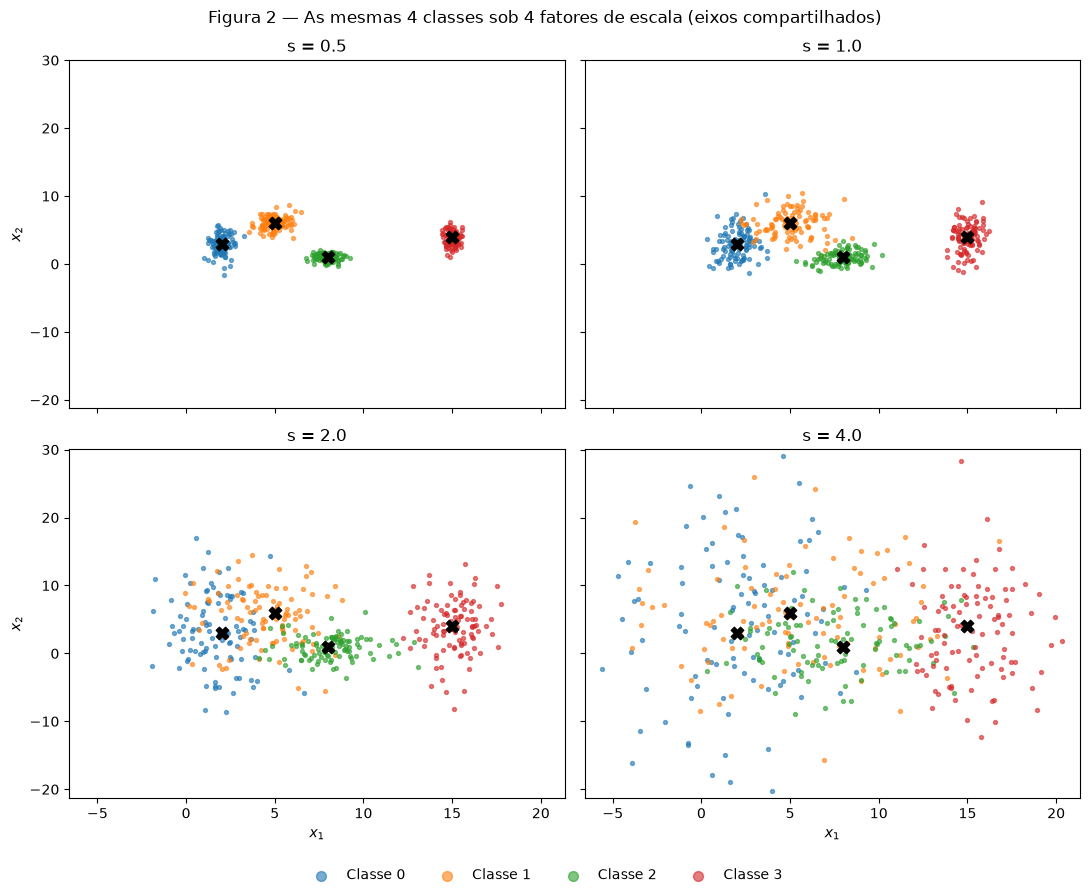

In [3]:
datasets = {1.0: (X1, y1)}
for s in (0.5, 2.0, 4.0):
    datasets[s] = gen_clouds(rng, scale=s)

SCALES = [0.5, 1.0, 2.0, 4.0]

# limites de eixo compartilhados, calculados sobre a união dos 4 datasets
allX = np.vstack([datasets[s][0] for s in SCALES])
xlim = (allX[:, 0].min() - 1, allX[:, 0].max() + 1)
ylim = (allX[:, 1].min() - 1, allX[:, 1].max() + 1)

fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True)
for ax, s in zip(axes.ravel(), SCALES):
    X, y = datasets[s]
    for k in range(4):
        pts = X[y == k]
        ax.scatter(pts[:, 0], pts[:, 1], s=8, alpha=0.6, color=COLORS[k],
                   label=f"Classe {k}" if s == 0.5 else None)
    ax.scatter(MEANS[:, 0], MEANS[:, 1], marker="X", s=80, color="black", zorder=5)
    ax.set_title(f"s = {s}")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
for ax in axes[-1]:
    ax.set_xlabel("$x_1$")
for ax in axes[:, 0]:
    ax.set_ylabel("$x_2$")
fig.suptitle("Figura 2 — As mesmas 4 classes sob 4 fatores de escala (eixos compartilhados)")
fig.legend(loc="lower center", ncol=5, frameon=False, markerscale=2.5)
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

### Razão de separação $r_{ij}$ em $s = 1$

$$ r_{ij} = \frac{\lVert \mu_i - \mu_j \rVert}{\bar{\sigma}_i + \bar{\sigma}_j},
\qquad \bar{\sigma}_k = \frac{\sigma_{k,x} + \sigma_{k,y}}{2} $$

In [4]:
sig_bar = STDS.mean(axis=1)  # dispersão média de cada classe

rows = []
for i in range(4):
    for j in range(i + 1, 4):
        dist = np.linalg.norm(MEANS[i] - MEANS[j])
        r = dist / (sig_bar[i] + sig_bar[j])
        rows.append({"par": f"({i}, {j})", "‖μi − μj‖": round(dist, 3),
                     "σ̄i + σ̄j": round(sig_bar[i] + sig_bar[j], 2), "r_ij": round(r, 3)})
r_table = pd.DataFrame(rows)
print(r_table.to_string(index=False))

r_min = r_table.loc[r_table["r_ij"].idxmin()]
print(f"\nMenor razão: par {r_min['par']} com r = {r_min['r_ij']}")
print(f"Como r_ij ∝ 1/s, em s = 2 esse valor passa a {r_min['r_ij'] / 2:.3f}")

   par  ‖μi − μj‖  σ̄i + σ̄j  r_ij
(0, 1)      4.243       3.20 1.326
(0, 2)      6.325       2.55 2.480
(0, 3)     13.038       2.90 4.496
(1, 2)      5.831       2.45 2.380
(1, 3)     10.198       2.80 3.642
(2, 3)      7.616       2.15 3.542

Menor razão: par (0, 1) com r = 1.326
Como r_ij ∝ 1/s, em s = 2 esse valor passa a 0.663


O par mais próximo é **(0, 1)**, com $r_{01} = 1.326$ — todos os demais pares têm
$r_{ij} \geq 2.38$. Como as médias não mudam com $s$, vale $r_{ij} \propto 1/s$: em
$s = 2$, o menor valor passa a $r_{01} = 1.326 / 2 = \mathbf{0.663}$, sem gerar nada
de novo.

### Mixing rate

Fração de pontos cujo centro de classe mais próximo (entre as 4 médias teóricas)
**não** é o da própria classe — medida puramente geométrica, nada é treinado.

mixing rate (s = 0.5): 0.0000  (0/400 pontos)
mixing rate (s = 1.0): 0.0500  (20/400 pontos)
mixing rate (s = 2.0): 0.1925  (77/400 pontos)
mixing rate (s = 4.0): 0.4825  (193/400 pontos)


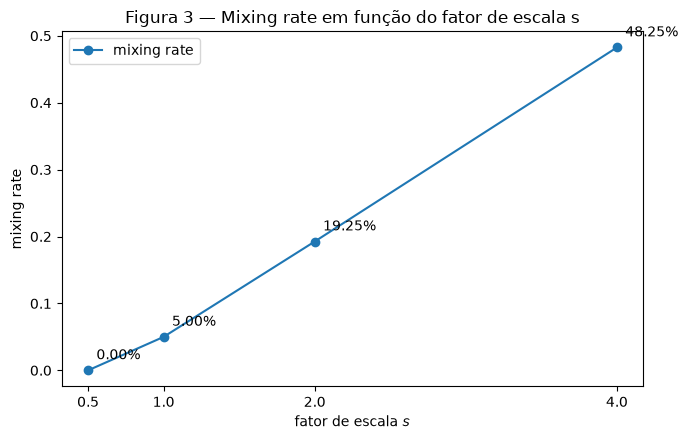

In [5]:
def mixing_rate(X, y):
    """Fração de pontos mais próximos do centro de outra classe."""
    d2 = ((X[:, None, :] - MEANS[None, :, :]) ** 2).sum(axis=-1)  # (400, 4)
    return float((d2.argmin(axis=1) != y).mean())

mix = {s: mixing_rate(*datasets[s]) for s in SCALES}
for s, m in mix.items():
    print(f"mixing rate (s = {s}): {m:.4f}  ({int(m * 400)}/400 pontos)")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(SCALES, [mix[s] for s in SCALES], marker="o", color="tab:blue",
        label="mixing rate")
for s in SCALES:
    ax.annotate(f"{mix[s]:.2%}", (s, mix[s]), textcoords="offset points", xytext=(6, 8))
ax.set_title("Figura 3 — Mixing rate em função do fator de escala s")
ax.set_xlabel("fator de escala $s$")
ax.set_ylabel("mixing rate")
ax.set_xticks(SCALES)
ax.legend()
plt.tight_layout()
plt.show()

Valores: **0.00%** ($s{=}0.5$), **5.00%** ($s{=}1$), **19.25%** ($s{=}2$),
**48.25%** ($s{=}4$).

**A partir de que escala as retas deixam de separar?** A partir de $s = 2$. Em
$s = 1$ a mistura é de 5% e concentra-se no par (0, 1) — um conjunto de retas ainda
separa quase tudo. Em $s = 2$ a mistura salta para 19.25% e o menor
$r_{ij}$ cai para **0.663**: a distância entre os centros 0 e 1 torna-se *menor* que
a soma das dispersões médias das duas nuvens, ou seja, as nuvens se interpenetram e
nenhum arranjo de retas evita uma fração grande de erro. Em $s = 4$
($r_{01} = 0.33$), quase metade dos pontos está mais perto de um centro alheio.

## C — Analysis

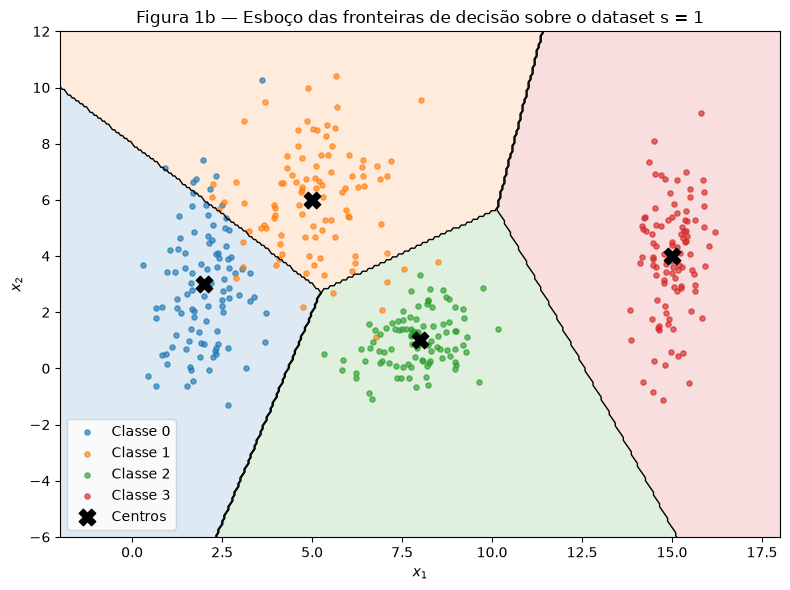

In [6]:
# Esboço das fronteiras: partição do plano pela regra do centro mais próximo
# (fronteiras lineares, aproximação do que uma rede pequena aprenderia).
gx, gy = np.meshgrid(np.linspace(*xlim, 500), np.linspace(*ylim, 500))
grid = np.stack([gx.ravel(), gy.ravel()], axis=1)
Z = ((grid[:, None, :] - MEANS[None, :, :]) ** 2).sum(-1).argmin(1).reshape(gx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(gx, gy, Z, levels=[-0.5, 0.5, 1.5, 2.5, 3.5],
            colors=COLORS, alpha=0.15)
ax.contour(gx, gy, Z, levels=[0.5, 1.5, 2.5], colors="black", linewidths=1)
for k in range(4):
    pts = X1[y1 == k]
    ax.scatter(pts[:, 0], pts[:, 1], s=14, alpha=0.65, color=COLORS[k], label=f"Classe {k}")
ax.scatter(MEANS[:, 0], MEANS[:, 1], marker="X", s=140, color="black", zorder=5,
           label="Centros")
ax.set_title("Figura 1b — Esboço das fronteiras de decisão sobre o dataset s = 1")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_xlim(-2, 18)
ax.set_ylim(-6, 12)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

**Sobreposição em $s = 1$.** A única região de conflito relevante é entre as classes
0 e 1 ($r_{01} = 1.326$): a cauda vertical da classe 0 invade a nuvem da classe 1.
Os pares restantes têm $r_{ij} \geq 2.38$ e praticamente não se tocam.

**Uma única fronteira linear?** Não — uma reta divide o plano em apenas duas regiões,
e aqui há 4 classes. **Um conjunto de fronteiras lineares?** Sim, quase: a partição
esboçada na Figura 1b (fronteiras lineares entre centros vizinhos) classifica
corretamente 95% dos pontos; os 5% de erro ficam na zona 0–1, onde as nuvens se
sobrepõem de fato.

**Esboço.** As fronteiras da Figura 1b são as que uma rede tenderia a aprender:
cortes aproximadamente lineares entre centros vizinhos. Uma rede com mais capacidade
curvaria o corte 0–1 (a classe 0 é muito mais alongada em $x_2$ que a 1), mas nenhuma
fronteira elimina a região onde as duas distribuições se misturam.

**Relação com o item B.** Quanto maior a dispersão, maior a área em que as densidades
das classes se sobrepõem — e todo ponto nessa área pode pertencer a mais de uma classe.
Esse é um **erro irredutível**, que pertence aos dados: a mixing rate de 5% → 19% → 48%
quantifica exatamente o crescimento da região onde qualquer classificador,
por melhor que seja, necessariamente erra.

---

> **Aprendizado.** A dificuldade de classificação é geométrica e mensurável antes de
> qualquer treinamento: o que importa é a distância entre centros **relativa à
> dispersão** ($r_{ij}$), não a distância absoluta. Quando $r_{ij}$ cai abaixo de ~1,
> as nuvens se interpenetram e surge um erro irredutível que nenhuma arquitetura
> remove.